In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory

/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


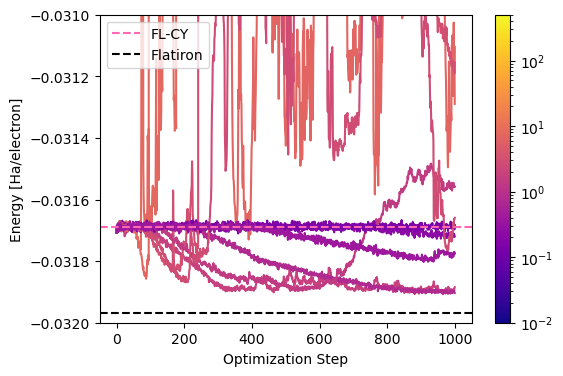

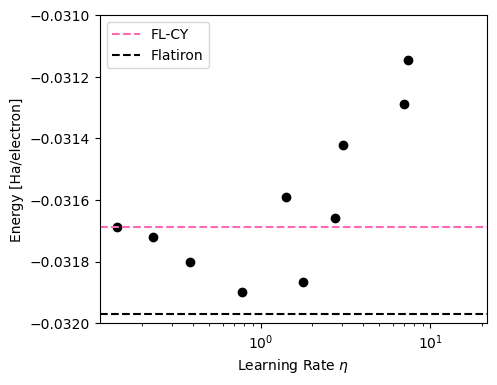

In [2]:
path = "nsjb-final/{}/rs{}_trial{}/{}"

init_methods = ["2-SJB-FL", "2-SJB-WC", "N-SJB-FL"]
init_method = init_methods[2]
r_ws = "30"

cmap = plt.cm.plasma
norm = mpl.colors.LogNorm(1e-2, 5e2)

final_vals = []

plt.figure(figsize=(6,4))

# "r_ws" : ( FL_ref , WC_ref, flatiron )
hard_vals = {
    "10" : ( -0.084474 , np.nan , np.nan ),
    "20" : ( -0.045929 , -0.045975 , -0.04637 ),
    "30" : ( -0.031689 , -0.031807 , -0.03197 ),
    "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
    "50" : ( -0.0196589 , -0.0197745 , -0.019829 )
}

for trial in range(16):

    try:
        energy_traj = np.loadtxt(path.format(
            init_method, r_ws, str(trial), "energy_traj.txt"
        ))
        eta = np.loadtxt(path.format(
            init_method, r_ws, str(trial), "hyperparameters.txt"
        ))
    
        (mean,_) = trajectory.getStatistics(path.format(
            init_method, r_ws, str(trial), "statistics.txt"
        ))
        final_vals.append([eta, mean])
    
        if mean is None or mean > 0:
            continue;
        
        color = cmap(norm(eta))
        plt.plot(energy_traj, color=color)
        
    except:
        continue;

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

min_val = np.nanmin([hard_vals[r_ws][0],hard_vals[r_ws][2]])
max_val = np.nanmax([hard_vals[r_ws][0],hard_vals[r_ws][2]])
plt.ylim([1.1*min_val,0.9*max_val])
plt.ylim(-0.032, -0.031)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # older matplotlib compatibility
cbar = plt.colorbar(sm, ax=plt.gca())

plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

final_vals = np.array(final_vals)

plt.figure(figsize=(5,4))
plt.scatter(final_vals[:,0], final_vals[:,1], color='black')
plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')
plt.xscale('log')
plt.xlabel(r"Learning Rate $\eta$")
plt.ylabel("Energy [Ha/electron]")
plt.ylim(-0.032, -0.031)
plt.legend()
plt.show()

In [7]:
print(np.array(np.sort(final_vals[:,0])))
print(final_vals)

[array(0.14350422) array(0.23448683) array(0.38551407) array(0.7735373)
 array(1.41523003) array(1.78190177) array(2.73404581) array(3.0644149)
 array(6.99769304) array(7.34133576) array(13.70688737) array(14.43584825)
 array(17.00094926) array(18.97220419) array(60.02026857)
 array(79.97545254)]
[[array(79.97545254) None]
 [array(1.78190177) -0.0318670879]
 [array(18.97220419) None]
 [array(60.02026857) None]
 [array(0.7735373) -0.031900402]
 [array(6.99769304) -0.0312890748]
 [array(3.0644149) -0.0314212001]
 [array(17.00094926) 0.0192014067]
 [array(1.41523003) -0.0315911367]
 [array(14.43584825) None]
 [array(0.23448683) -0.0317194591]
 [array(13.70688737) None]
 [array(7.34133576) -0.0311455265]
 [array(0.14350422) -0.0316869874]
 [array(2.73404581) -0.0316592842]
 [array(0.38551407) -0.0318024519]]
